# Gradient Descent on House Prices Dataset


Model Performance:
Mean Squared Error: 0.5023642289784899
Mean Absolute Error: 0.519094319027634
R2 Score: 0.6529242642153175
Coefficients (scaled):
  area                                +0.2738
  bedrooms                            +0.0303
  bathrooms                           +0.2940
  stories                             +0.1890
  mainroad                            +0.0686
  guestroom                           +0.0474
  basement                            +0.0996
  hotwaterheating                     +0.0766
  airconditioning                     +0.1968
  parking                             +0.1036
  prefarea                            +0.1429
  furnishingstatus_semi-furnished     -0.0335
  furnishingstatus_unfurnished        -0.1038


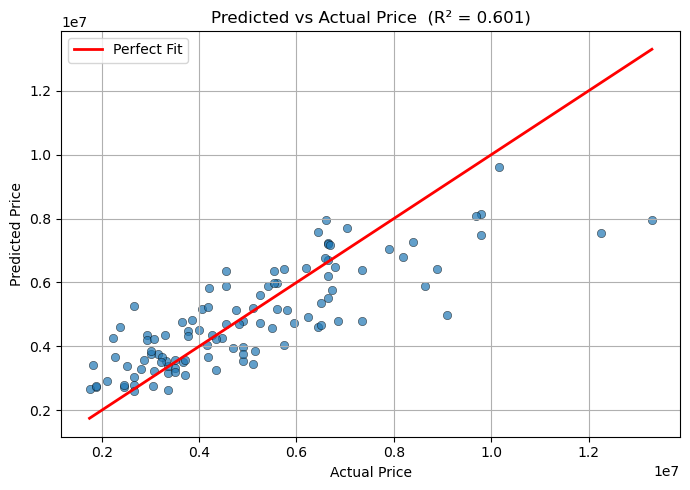

In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score


df = pd.read_csv("Housing.csv")

binary_cols = ["mainroad", "guestroom", "basement", "hotwaterheating", "airconditioning", "prefarea"]
for col in binary_cols:
    df[col] = df[col].map({"yes": 1, "no": 0})

df = pd.get_dummies(df, columns=["furnishingstatus"], drop_first=True)


feature_cols = [
    "area", "bedrooms", "bathrooms", "stories",
    "mainroad", "guestroom", "basement", "hotwaterheating",
    "airconditioning", "parking", "prefarea",
    "furnishingstatus_semi-furnished", "furnishingstatus_unfurnished"
]

X = df[feature_cols]
y = df["price"]

scaler_X = StandardScaler()
scaler_y = StandardScaler()

X_scaled = scaler_X.fit_transform(X)
y_scaled = scaler_y.fit_transform(y.values.reshape(-1, 1)).ravel()

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_scaled, test_size=0.2, random_state=42
)


model = LinearRegression()
model.fit(X_train, y_train)


y_pred = model.predict(X_test)

y_test_actual = scaler_y.inverse_transform(y_test.reshape(-1, 1)).ravel()
y_pred_actual = scaler_y.inverse_transform(y_pred.reshape(-1, 1)).ravel()


print("\nModel Performance:")
print("Mean Squared Error:", mean_squared_error(y_test, y_pred))
print("Mean Absolute Error:", mean_absolute_error(y_test, y_pred))
print("R2 Score:", r2_score(y_test, y_pred))


print("Coefficients (scaled):")
for feat, coef in zip(feature_cols, model.coef_):
    print(f"  {feat:<35} {coef:+.4f}")



plt.figure(figsize=(7, 5))
plt.scatter(y_test_actual, y_pred_actual, alpha=0.7, edgecolors="k", linewidths=0.4)
min_val = min(y_test_actual.min(), y_pred_actual.min())
max_val = max(y_test_actual.max(), y_pred_actual.max())
plt.plot([min_val, max_val], [min_val, max_val], color="red", linewidth=2, label="Perfect Fit")
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title(f"Predicted vs Actual Price  (R² = {r2:.3f})")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()




Final Weights:
area            +0.2833
bedrooms        +0.0453
bathrooms       +0.2653
stories         +0.2091
mainroad        +0.0785
guestroom       +0.0615
basement        +0.0894
hotwaterheating +0.0958
airconditioning +0.2151
parking         +0.1276
prefarea        +0.1478
furnishingstatus_semi-furnished -0.0122
furnishingstatus_unfurnished -0.1032
Intercept (b): 3.256762851245381e-16

Model Performance:
Mean Squared Error (MSE): 1111187723373.3696
Mean Absolute Error (MAE): 775055.9309979139
R2 Score: 0.6818018482421784


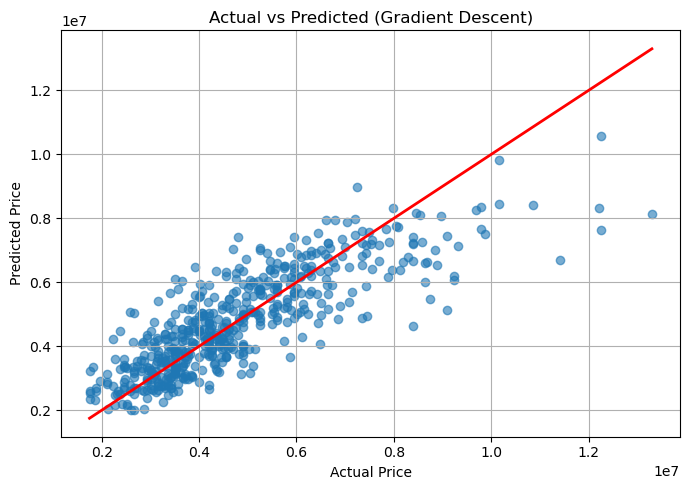

In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score


df = pd.read_csv("Housing.csv")
df = df.dropna()

binary_cols = ["mainroad", "guestroom", "basement", "hotwaterheating", "airconditioning", "prefarea"]
for col in binary_cols:
    df[col] = df[col].map({"yes": 1, "no": 0})

df = pd.get_dummies(df, columns=["furnishingstatus"], drop_first=True)


feature_cols = [
    "area", "bedrooms", "bathrooms", "stories",
    "mainroad", "guestroom", "basement", "hotwaterheating",
    "airconditioning", "parking", "prefarea",
    "furnishingstatus_semi-furnished", "furnishingstatus_unfurnished"
]

X = df[feature_cols].values
y = df[["price"]].values

scaler_minmax_X = MinMaxScaler()
scaler_minmax_y = MinMaxScaler()

X_normalized = scaler_minmax_X.fit_transform(X)
y_normalized = scaler_minmax_y.fit_transform(y)

scaler_std_X = StandardScaler()
scaler_std_y = StandardScaler()

X_scaled = scaler_std_X.fit_transform(X)
y_scaled = scaler_std_y.fit_transform(y)

n_samples, n_features = X_scaled.shape
W = np.zeros((n_features, 1))
b = 0.0
learning_rate = 0.01
iters = 1000
loss_list = []

for i in range(iters):
    y_pred = np.dot(X_scaled, W) + b
    error = y_pred - y_scaled
    loss = np.mean(error ** 2)
    loss_list.append(loss)
    dW = (2/n_samples) * np.dot(X_scaled.T, error)
    db = (2/n_samples) * np.sum(error)
    W = W - learning_rate * dW
    b = b - learning_rate * db


print("Final Weights:")
for feat, weight in zip(feature_cols, W):
    print(f"{feat:<15} {weight[0]:+.4f}")
print("Intercept (b):", b)


y_pred_scaled = np.dot(X_scaled, W) + b
y_pred_actual = scaler_std_y.inverse_transform(y_pred_scaled)
y_actual = scaler_std_y.inverse_transform(y_scaled)
y_actual_flat = y_actual.ravel()
y_pred_flat = y_pred_actual.ravel()


mse = mean_squared_error(y_actual_flat, y_pred_flat)
mae = mean_absolute_error(y_actual_flat, y_pred_flat)
r2 = r2_score(y_actual_flat, y_pred_flat)

print("\nModel Performance:")
print("Mean Squared Error (MSE):", mse)
print("Mean Absolute Error (MAE):", mae)
print("R2 Score:", r2)


plt.figure(figsize=(7, 5))
plt.scatter(y_actual, y_pred_actual, alpha=0.6)
min_val = min(y_actual.min(), y_pred_actual.min())
max_val = max(y_actual.max(), y_pred_actual.max())
plt.plot([min_val, max_val], [min_val, max_val], linewidth=2,color="red")
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted (Gradient Descent)")
plt.grid(True)
plt.tight_layout()
plt.show()